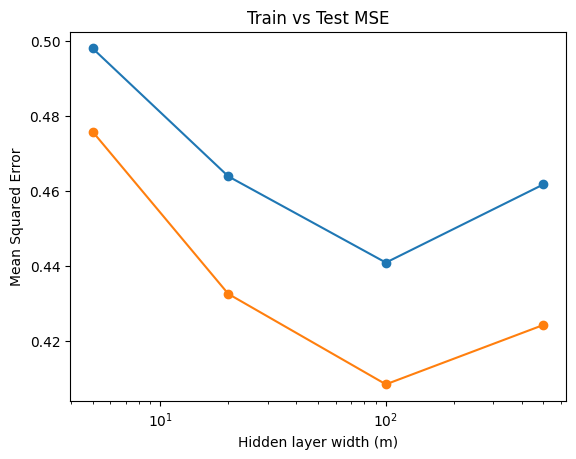

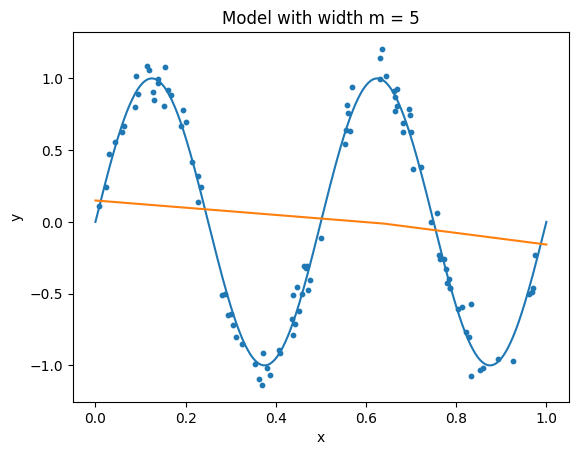

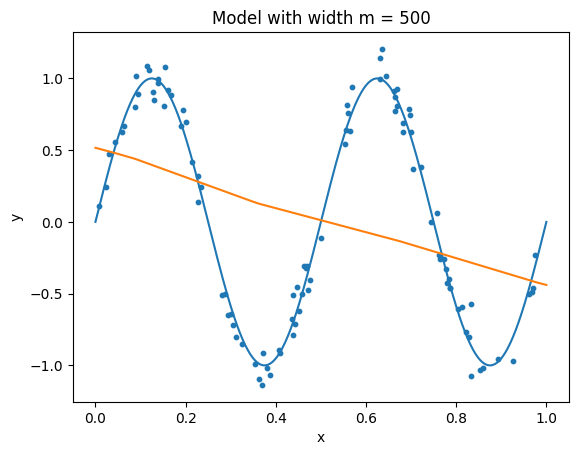

Widths: [5, 20, 100, 500]
Train MSE: [np.float64(0.4979212455836366), np.float64(0.46380289265402985), np.float64(0.4408235647813534), np.float64(0.46166931878629386)]
Test MSE: [np.float64(0.47572642608781196), np.float64(0.4324831135944527), np.float64(0.4083919032277322), np.float64(0.42421683983892366)]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

# Set random seed for reproducibility
rng = np.random.default_rng(42)

# Target function
def f(x):
    return np.sin(4 * np.pi * x)

# Generate training and test data
n_train = 100
n_test = 1000

X_train = rng.uniform(0, 1, size=(n_train, 1))
y_train = f(X_train[:, 0]) + rng.normal(0, 0.1, size=n_train)

X_test = rng.uniform(0, 1, size=(n_test, 1))
y_test = f(X_test[:, 0]) + rng.normal(0, 0.1, size=n_test)

widths = [5, 20, 100, 500]
train_mse = []
test_mse = []
models = {}

for m in widths:
    model = MLPRegressor(
        hidden_layer_sizes=(m,),
        activation="relu",
        solver="adam",
        max_iter=5000,
        random_state=42,
    )
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_mse.append(mean_squared_error(y_train, y_train_pred))
    test_mse.append(mean_squared_error(y_test, y_test_pred))
    models[m] = model

# Plot MSE vs width
plt.figure()
plt.plot(widths, train_mse, marker='o')
plt.plot(widths, test_mse, marker='o')
plt.xlabel("Hidden layer width (m)")
plt.ylabel("Mean Squared Error")
plt.title("Train vs Test MSE")
plt.xscale("log")
plt.show()

# Plot predictions for smallest and largest networks
x_plot = np.linspace(0, 1, 500).reshape(-1, 1)
y_true_plot = f(x_plot[:, 0])

for m in [5, 500]:
    plt.figure()
    plt.plot(x_plot[:, 0], y_true_plot)
    plt.scatter(X_train[:, 0], y_train, s=10)
    plt.plot(x_plot[:, 0], models[m].predict(x_plot))
    plt.title(f"Model with width m = {m}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()

print("Widths:", widths)
print("Train MSE:", train_mse)
print("Test MSE:", test_mse)


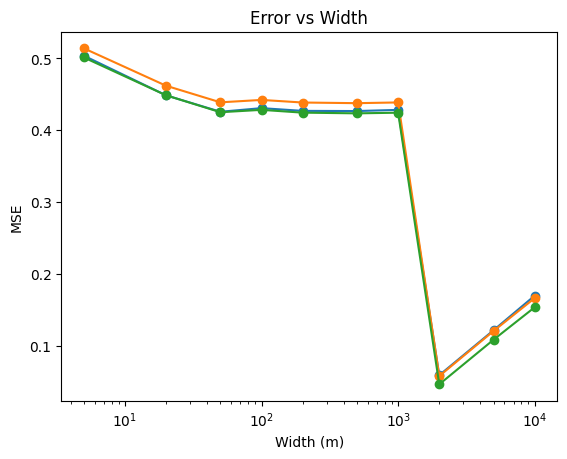

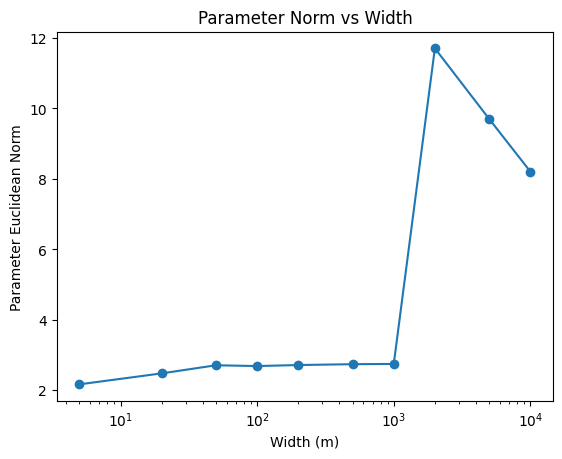

Widths: [5, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000]
Train MSE: [np.float64(0.5035913174532085), np.float64(0.4483945861027179), np.float64(0.4255250938459702), np.float64(0.43055662576802156), np.float64(0.42675682631070255), np.float64(0.42652665775404425), np.float64(0.42815319029056254), np.float64(0.05877041388462465), np.float64(0.12150008688994443), np.float64(0.16960429892156095)]
Test MSE (noisy): [np.float64(0.5138349520311188), np.float64(0.46174518781709917), np.float64(0.4386497796990357), np.float64(0.4420087061049555), np.float64(0.4383874183436659), np.float64(0.43748533683425544), np.float64(0.43850098112498914), np.float64(0.057617234472717625), np.float64(0.12042064583749042), np.float64(0.16616631849599608)]
Test MSE (clean): [np.float64(0.5011111487768186), np.float64(0.44845819123763275), np.float64(0.42489513235478055), np.float64(0.42818886378856263), np.float64(0.4242881335678777), np.float64(0.42332548379067936), np.float64(0.42421408845996994), np.floa

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

rng = np.random.default_rng(0)

def f(x):
    return np.sin(4 * np.pi * x)

# Data
n_train = 100
n_test = 1000
noise_std = 0.1

X_train = rng.uniform(0, 1, size=(n_train, 1))
y_train_clean = f(X_train[:, 0])
y_train = y_train_clean + rng.normal(0, noise_std, size=n_train)

X_test = rng.uniform(0, 1, size=(n_test, 1))
y_test_clean = f(X_test[:, 0])
y_test_noisy = y_test_clean + rng.normal(0, noise_std, size=n_test)

widths = [5, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000]
n_repeats = 5

results = {m: {"train": [], "test_noisy": [], "test_clean": [], "norm": []} for m in widths}

for m in widths:
    for rep in range(n_repeats):
        model = MLPRegressor(
            hidden_layer_sizes=(m,),
            activation="relu",
            solver="adam",
            alpha=0.0,
            max_iter=5000,
            random_state=rep,
        )
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        train_err = mean_squared_error(y_train, y_train_pred)
        test_noisy_err = mean_squared_error(y_test_noisy, y_test_pred)
        test_clean_err = mean_squared_error(y_test_clean, y_test_pred)

        # Parameter norm
        sq_sum = 0.0
        for coef, intercept in zip(model.coefs_, model.intercepts_):
            sq_sum += np.sum(coef**2) + np.sum(intercept**2)
        param_norm = np.sqrt(sq_sum)

        results[m]["train"].append(train_err)
        results[m]["test_noisy"].append(test_noisy_err)
        results[m]["test_clean"].append(test_clean_err)
        results[m]["norm"].append(param_norm)

# Aggregate means
train_means = [np.mean(results[m]["train"]) for m in widths]
test_noisy_means = [np.mean(results[m]["test_noisy"]) for m in widths]
test_clean_means = [np.mean(results[m]["test_clean"]) for m in widths]
norm_means = [np.mean(results[m]["norm"]) for m in widths]

# Plot errors vs width
plt.figure()
plt.plot(widths, train_means, marker='o')
plt.plot(widths, test_noisy_means, marker='o')
plt.plot(widths, test_clean_means, marker='o')
plt.xscale("log")
plt.xlabel("Width (m)")
plt.ylabel("MSE")
plt.title("Error vs Width")
plt.show()

# Plot parameter norm vs width
plt.figure()
plt.plot(widths, norm_means, marker='o')
plt.xscale("log")
plt.xlabel("Width (m)")
plt.ylabel("Parameter Euclidean Norm")
plt.title("Parameter Norm vs Width")
plt.show()

print("Widths:", widths)
print("Train MSE:", train_means)
print("Test MSE (noisy):", test_noisy_means)
print("Test MSE (clean):", test_clean_means)
print("Param Norms:", norm_means)


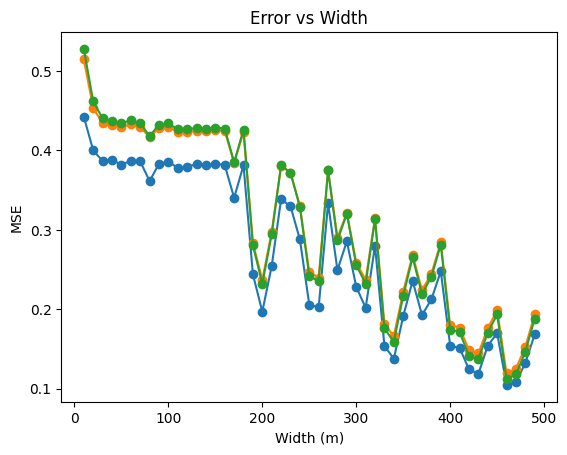

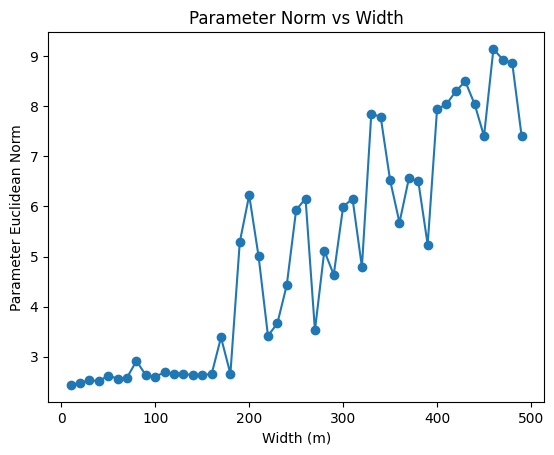

Widths: [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490]
Train MSE: [np.float64(0.4423949953014835), np.float64(0.40007304098451596), np.float64(0.3867091346925509), np.float64(0.3885660864185093), np.float64(0.38171061731168515), np.float64(0.3872352526090904), np.float64(0.38632587268000457), np.float64(0.3614155720100077), np.float64(0.38308665512812856), np.float64(0.38608134635055064), np.float64(0.3779185165694058), np.float64(0.37948312538437196), np.float64(0.38286064252607943), np.float64(0.38128892627371236), np.float64(0.3835506033111896), np.float64(0.38138681409263075), np.float64(0.3404138358407867), np.float64(0.3813641128662365), np.float64(0.24386023999319906), np.float64(0.19690762273682047), np.float64(0.25430828840342456), np.float64(0.33832378466352747), np.float64(0.3298644531689

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

rng = np.random.default_rng(0)

def f(x):
    return np.sin(4 * np.pi * x)

# Data
n_train = 30
n_test = 30
noise_std = 0.1

X_train = rng.uniform(0, 1, size=(n_train, 1))
y_train_clean = f(X_train[:, 0])
y_train = y_train_clean + rng.normal(0, noise_std, size=n_train)

X_test = rng.uniform(0, 1, size=(n_test, 1))
y_test_clean = f(X_test[:, 0])
y_test_noisy = y_test_clean + rng.normal(0, noise_std, size=n_test)

widths = list(range(10, 100, 10))
n_repeats = 5

results = {m: {"train": [], "test_noisy": [], "test_clean": [], "norm": []} for m in widths}

for m in widths:
    for rep in range(n_repeats):
        model = MLPRegressor(
            hidden_layer_sizes=(m,),
            activation="relu",
            solver="adam",
            alpha=0.0,
            max_iter=100000,
            random_state=rep,
        )
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        train_err = mean_squared_error(y_train, y_train_pred)
        test_noisy_err = mean_squared_error(y_test_noisy, y_test_pred)
        test_clean_err = mean_squared_error(y_test_clean, y_test_pred)

        # Parameter norm
        sq_sum = 0.0
        for coef, intercept in zip(model.coefs_, model.intercepts_):
            sq_sum += np.sum(coef**2) + np.sum(intercept**2)
        param_norm = np.sqrt(sq_sum)

        results[m]["train"].append(train_err)
        results[m]["test_noisy"].append(test_noisy_err)
        results[m]["test_clean"].append(test_clean_err)
        results[m]["norm"].append(param_norm)

# Aggregate means
train_means = [np.mean(results[m]["train"]) for m in widths]
test_noisy_means = [np.mean(results[m]["test_noisy"]) for m in widths]
test_clean_means = [np.mean(results[m]["test_clean"]) for m in widths]
norm_means = [np.mean(results[m]["norm"]) for m in widths]

# Plot errors vs width
plt.figure()
plt.plot(widths, train_means, marker='o')
plt.plot(widths, test_noisy_means, marker='o')
plt.plot(widths, test_clean_means, marker='o')
# plt.xscale("log")
plt.xlabel("Width (m)")
plt.ylabel("MSE")
plt.title("Error vs Width")
plt.show()

# Plot parameter norm vs width
plt.figure()
plt.plot(widths, norm_means, marker='o')
# plt.xscale("log")
plt.xlabel("Width (m)")
plt.ylabel("Parameter Euclidean Norm")
plt.title("Parameter Norm vs Width")
plt.show()

print("Widths:", widths)
print("Train MSE:", train_means)
print("Test MSE (noisy):", test_noisy_means)
print("Test MSE (clean):", test_clean_means)
print("Param Norms:", norm_means)


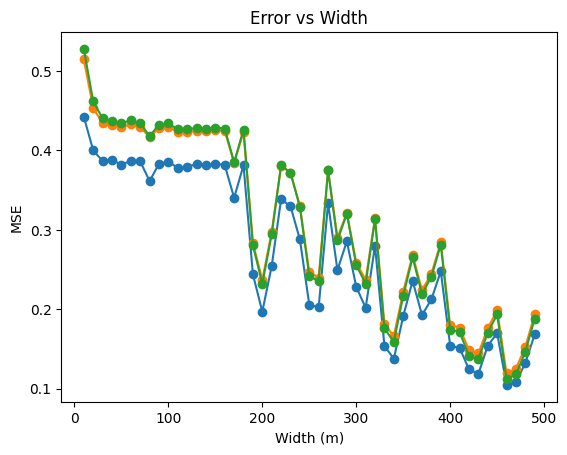

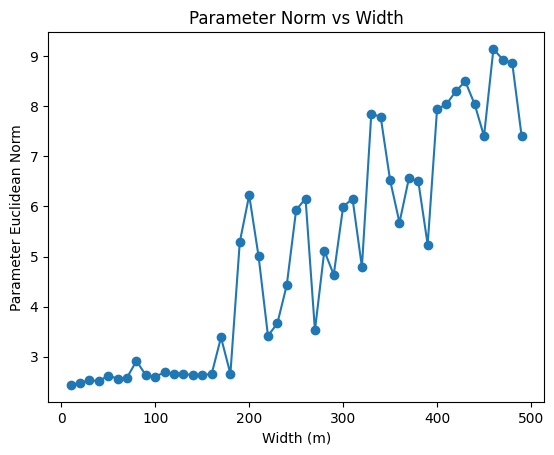

Widths: [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490]
Train MSE: [np.float64(0.4423949953014835), np.float64(0.40007304098451596), np.float64(0.3867091346925509), np.float64(0.3885660864185093), np.float64(0.38171061731168515), np.float64(0.3872352526090904), np.float64(0.38632587268000457), np.float64(0.3614155720100077), np.float64(0.38308665512812856), np.float64(0.38608134635055064), np.float64(0.3779185165694058), np.float64(0.37948312538437196), np.float64(0.38286064252607943), np.float64(0.38128892627371236), np.float64(0.3835506033111896), np.float64(0.38138681409263075), np.float64(0.3404138358407867), np.float64(0.3813641128662365), np.float64(0.24386023999319906), np.float64(0.19690762273682047), np.float64(0.25430828840342456), np.float64(0.33832378466352747), np.float64(0.3298644531689

In [10]:
# Plot errors vs width
plt.figure()
plt.plot(widths, train_means, marker='o')
plt.plot(widths, test_noisy_means, marker='o')
plt.plot(widths, test_clean_means, marker='o')
# plt.xscale("log")
plt.xlabel("Width (m)")
plt.ylabel("MSE")
plt.title("Error vs Width")
plt.show()

# Plot parameter norm vs width
plt.figure()
plt.plot(widths, norm_means, marker='o')
# plt.xscale("log")
plt.xlabel("Width (m)")
plt.ylabel("Parameter Euclidean Norm")
plt.title("Parameter Norm vs Width")
plt.show()

print("Widths:", widths)
print("Train MSE:", train_means)
print("Test MSE (noisy):", test_noisy_means)
print("Test MSE (clean):", test_clean_means)
print("Param Norms:", norm_means)